In [54]:
import re

import ftfy
import matplotlib.pyplot as plt
import pandas as pd

In [73]:
TARGET_CLASSES = ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']

MENTAL_HEALTH_PATH = '../data/raw/Combined Data.csv'
SUICIDE_PATH = '../data/raw/Suicide_Detection.csv'
EMOTIONS_TRAIN_PATH = '../data/raw/emotions_nlp_train.txt'
EMOTIONS_VAL_PATH = '../data/raw/emotions_nlp_val.txt'
EMOTIONS_TEST_PATH = '../data/raw/emotions_nlp_test.txt'
TWITTER_TRAIN_PATH  = '../data/raw/twitter_training.csv'
TWITTER_VAL_PATH    = '../data/raw/twitter_validation.csv'
TWITTER_TEST_PATH   = '../data/raw/twitter_test.csv'
CANCER_PATH = '../data/raw/cancer_mental_health.csv'

OUTPUT_LABELED_PATH = '../data/processed/cancer mental health final.csv'
OUTPUT_VOCAB_PATH   = '../data/processed/cancer vocab text.csv'

print('Target classes:', TARGET_CLASSES)

Target classes: ['Depression', 'Suicidal', 'Normal', 'Joy', 'Stress', 'Anxiety']


# Color map for each emotion

In [56]:
COLOR_MAP = {
    'Depression': '#1f77b4',   
    'Suicidal': '#d62728',  
    'Normal': '#2ca02c',       
    'Joy': '#ffcc00',         
    'Stress': '#ff7f0e',       
    'Anxiety': '#9467bd'       
}


# Text cleaning functions

In [57]:
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    text = ftfy.fix_text(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

def quick_clean(df, text_col='text'):
    #Drop any nulls, clean text, and filter out very short posts
    df = df.dropna(subset=[text_col]).copy()
    df[text_col] = df[text_col].astype(str).apply(fix_encoding)
    df = df[df[text_col].str.split().str.len() >= 10]
    return df

# Dataset Exploration Function

In [58]:
def explore_dataset(name, df, has_labels=True):
    word_counts = df['text'].str.split().str.len()
    print(f'{name}')
    print(f'Shape: {df.shape}')
    print(f'Text word count: min={word_counts.min()}, max={word_counts.max()}, mean={word_counts.mean():.1f}')
    print(f'Sample text: {df["text"].iloc[0][:150]}')
    print()
    
    if has_labels:
        counts = df['label'].value_counts()
        colors = [COLOR_MAP.get(label, 'gray') for label in counts.index]
        plt.figure(figsize=(8, 4))
        bars = plt.bar(counts.index, counts.values, color=colors)
        plt.title(f'{name} - Label Distribution')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.xticks(rotation=30)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=10)
        plt.tight_layout()
        plt.show()

# Load and Clean each dataset

## Mental Health Dataset

Mental Health Dataset 

Total Nulls per column
text     138
label      0
dtype: int64

label
Normal        16351
Depression    15404
Suicidal      10653
Anxiety        3888
Stress         2669
Name: count, dtype: int64

Dataset 1: Mental Health
Shape: (48965, 2)
Text word count: min=1.0, max=6300.0, mean=108.1
Sample text: oh my gosh



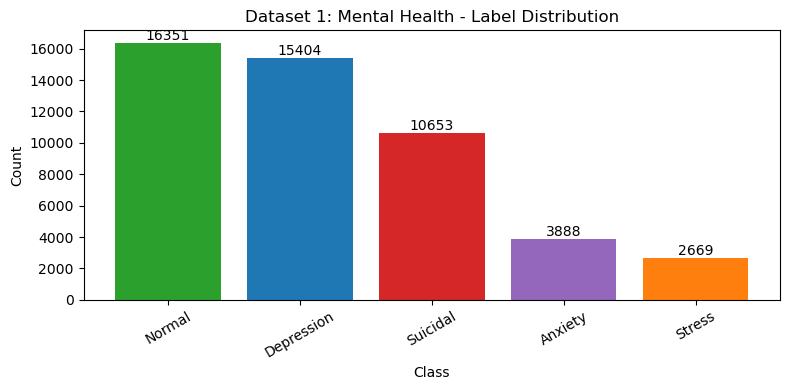

In [59]:
mh_df = pd.read_csv(MENTAL_HEALTH_PATH)
mh_df = mh_df.rename(columns={'statement': 'text', 'status': 'label', 'Mental Health Status': 'label'})
mh_df = mh_df[['text', 'label']].copy()
mh_df['label'] = mh_df['label'].str.strip()
mh_df = mh_df[mh_df['label'].isin(TARGET_CLASSES)]

print("Mental Health Dataset \n")
print("Total Nulls per column")
print(mh_df.isnull().sum())
print("")
print(mh_df['label'].value_counts())
print("")
explore_dataset('Dataset 1: Mental Health', mh_df)

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 1: Mental Health After Cleaning
Shape: (39940, 2)
Text word count: min=10, max=6300, mean=130.9
Sample text: trouble sleeping, confused mind, restless heart. All out of tune



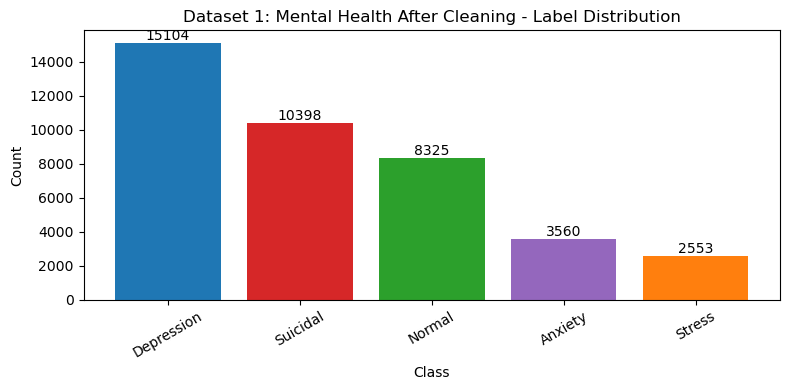

In [60]:
mh_df = quick_clean(mh_df)
print("Total Nulls per column")
print(mh_df.isnull().sum())
print("")
explore_dataset('Dataset 1: Mental Health After Cleaning', mh_df)

## SucideWatch Dataset

SuicideWatch Dataset 

Total Nulls per column
Unnamed: 0    0
text          0
orig_label    0
label         0
dtype: int64

label
Suicidal    116037
Name: count, dtype: int64

Dataset 2: SuicideWatch
Shape: (116037, 4)
Text word count: min=1, max=9684, mean=202.7
Sample text: Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse t



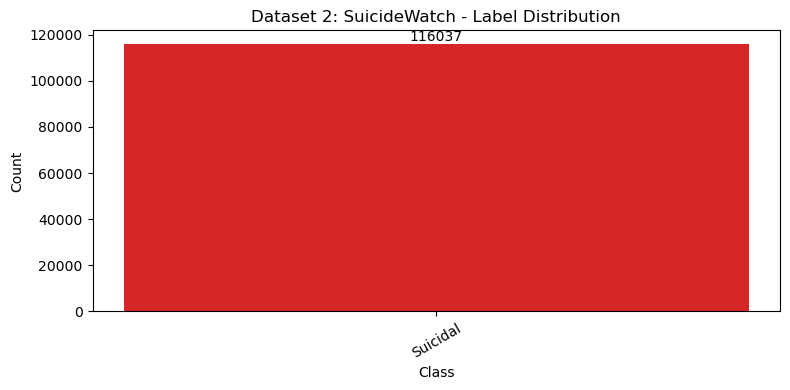

In [61]:
sw_df = pd.read_csv(SUICIDE_PATH)
sw_df = sw_df.rename(columns={'post': 'text', 'class': 'orig_label', 'label': 'orig_label'})
sw_df = sw_df[sw_df['orig_label'].str.lower().str.strip() == 'suicide']
sw_df['label'] = 'Suicidal'

print("SuicideWatch Dataset \n")
print("Total Nulls per column")
print(sw_df.isnull().sum())
print("")
print(sw_df['label'].value_counts())
print("")
explore_dataset('Dataset 2: SuicideWatch', sw_df)


Dataset 2: SuicideWatch after Cleaning and Sampling
Shape: (14602, 2)
Text word count: min=10, max=6781, mean=205.7
Sample text: Pls don't question people hereIf someone is talking to u about their struggles and stuff here pls don't question the credibility of their story. There



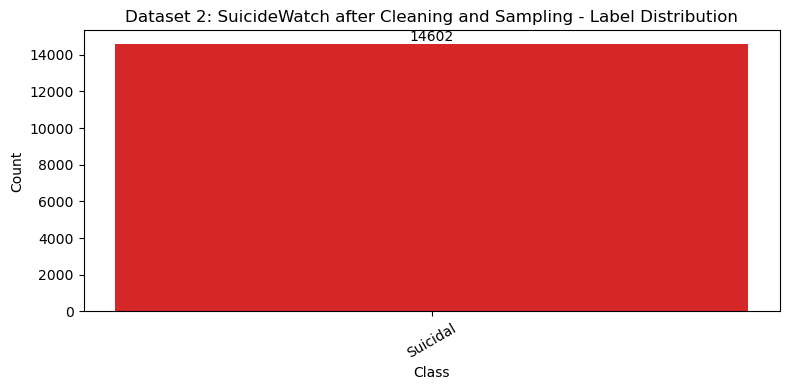

In [62]:
sw_df = quick_clean(sw_df) #Even though no null this is use to clean the text and filter out very short posts
sw_df = sw_df[['text', 'label']]

#Count how many suicidal are already in Mental Health dataset
mh_suicidal = len(mh_df[mh_df['label'] == 'Suicidal'])

#Total Suicidal needed is 25000
target_suicidal = 25000

#Calculate how many more is needed from the SuicideWatch dataset
sw_budget = max(target_suicidal - mh_suicidal, 0)
if len(sw_df) > sw_budget:
    sw_df = sw_df.sample(n=sw_budget, random_state=42)

explore_dataset('Dataset 2: SuicideWatch after Cleaning and Sampling', sw_df)

## Twitter Emotion Dataset

Twitter Emotion Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

label
Joy           8402
Depression    5797
Stress        2709
Anxiety       2373
Name: count, dtype: int64

Dataset 3: Twitter Emotion
Shape: (19281, 2)
Text word count: min=2, max=66, mean=19.1
Sample text: i didnt feel humiliated



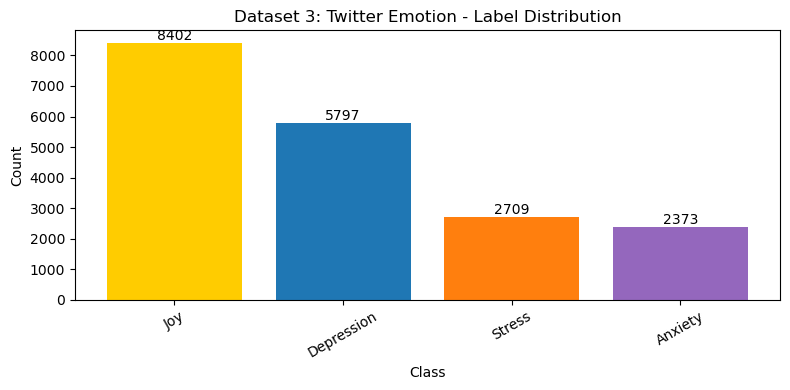

In [63]:
tw_train = pd.read_csv(TWITTER_TRAIN_PATH)
tw_val   = pd.read_csv(TWITTER_VAL_PATH)
tw_test  = pd.read_csv(TWITTER_TEST_PATH)
tw_df    = pd.concat([tw_train, tw_val, tw_test], ignore_index=True)

# 0=sadness=Depression, 1=Joy, 2=love=Joy, 3=anger=Stress, 4=fear=Anxiety, 5=surprise (drop)
TWITTER_LABEL_MAP = {0: 'Depression', 1: 'Joy', 2: 'Joy', 3: 'Stress', 4: 'Anxiety', 5: None}
tw_df['label'] = tw_df['label'].map(TWITTER_LABEL_MAP)

# Drop rows without valid label
tw_df = tw_df.dropna(subset=['label'])
tw_df = tw_df[['text', 'label']].copy()

print("Twitter Emotion Dataset \n")
print("Total Nulls per column")
print(tw_df.isnull().sum())
print("")
print(tw_df['label'].value_counts())
print("")

explore_dataset('Dataset 3: Twitter Emotion', tw_df)

After Cleaning 

Total Nulls per column
text     0
label    0
dtype: int64

label
Joy           6913
Depression    4417
Stress        2116
Anxiety       1846
Name: count, dtype: int64

Dataset 3: Twitter Emotion After Cleaning
Shape: (15292, 2)
Text word count: min=10, max=66, mean=22.3
Sample text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake



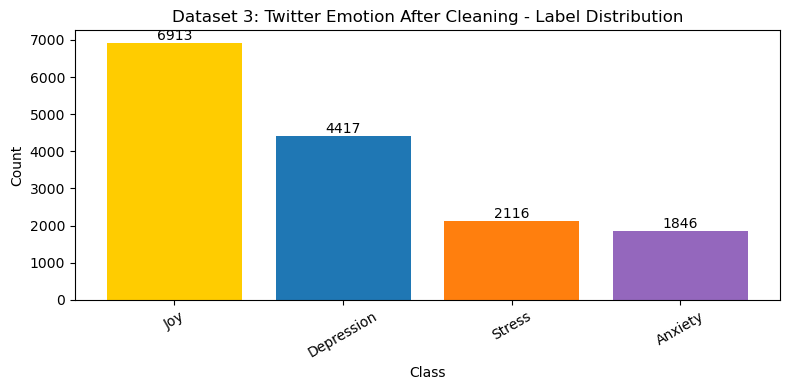

In [64]:
tw_df = quick_clean(tw_df)

print("After Cleaning \n")
print("Total Nulls per column")
print(tw_df.isnull().sum())
print("")
print(tw_df['label'].value_counts())
print("")

explore_dataset('Dataset 3: Twitter Emotion After Cleaning', tw_df)

## Emotions NLP dataset

Emotions NLP Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 4: Emotions NLP (Joy)
Shape: (6761, 2)
Text word count: min=2, max=64, mean=19.4
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



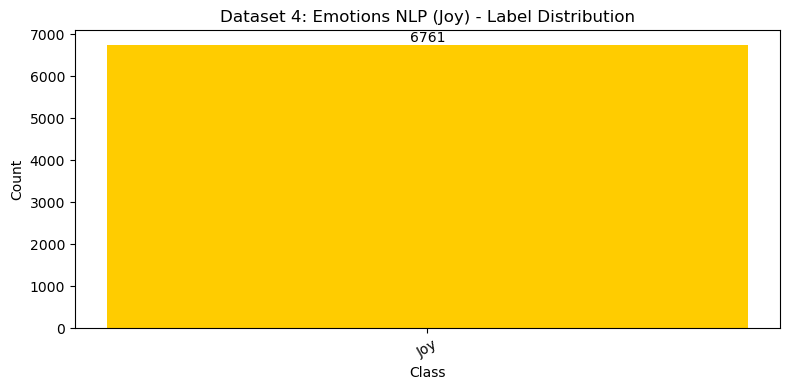

In [65]:
em_train = pd.read_csv(EMOTIONS_TRAIN_PATH, sep=';', header=None, names=['text', 'label'])
em_val = pd.read_csv(EMOTIONS_VAL_PATH, sep=';', header=None, names=['text', 'label'])
em_test = pd.read_csv(EMOTIONS_TEST_PATH, sep=';', header=None, names=['text', 'label'])
em_df = pd.concat([em_train, em_val, em_test], ignore_index=True)

em_df = em_df[em_df['label'] == 'joy'].copy()
em_df['label'] = 'Joy'

print("Emotions NLP Dataset \n")
print("Total Nulls per column")
print(em_df.isnull().sum())
print("")

explore_dataset('Dataset 4: Emotions NLP (Joy)', em_df)


Dataset 4: Emotions NLP (Joy) After Cleaning
Shape: (5506, 2)
Text word count: min=10, max=64, mean=22.3
Sample text: i have been with petronas for years i feel that petronas has performed well and made a huge profit



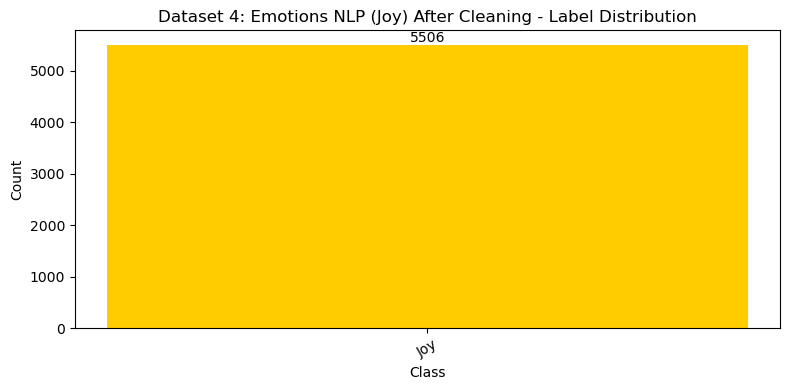

In [66]:
em_df = quick_clean(em_df) #Even though no null , this is use to clean the text and filter out very short posts
explore_dataset('Dataset 4: Emotions NLP (Joy) After Cleaning', em_df)

## Cancer Vocab Dataset

In [67]:
cancer_df = pd.read_csv(CANCER_PATH)
text_col = [c for c in cancer_df.columns if 'text' in c.lower() or 'state' in c.lower() or 'post' in c.lower()]
TEXT_COL = text_col[0] if text_col else cancer_df.columns[0]
cancer_df = cancer_df.rename(columns={TEXT_COL: 'text'})
cancer_df = cancer_df[['text']].copy()

print("Cancer Vocab Dataset \n")
print("Total Nulls per column")
print(em_df.isnull().sum())
print("")

explore_dataset('Dataset 5: Cancer Vocab', cancer_df, has_labels=False)

Cancer Vocab Dataset 

Total Nulls per column
text     0
label    0
dtype: int64

Dataset 5: Cancer Vocab
Shape: (10392, 1)
Text word count: min=1.0, max=5413.0, mean=234.1
Sample text: I know as parent of child with down syndrome that you have all hear that our child are at a high risk of leukemia as parent we read up on it and then 



In [68]:
cancer_df = quick_clean(cancer_df)
cancer_df['text'] = cancer_df['text'].str.replace(r'http\S+', '', regex=True).str.strip()
cancer_df = cancer_df.drop_duplicates(subset=['text'])
explore_dataset('Dataset 5: Cancer Vocab After Cleaning', cancer_df, has_labels=False)

Dataset 5: Cancer Vocab After Cleaning
Shape: (10274, 1)
Text word count: min=10, max=5413, mean=236.7
Sample text: I know as parent of child with down syndrome that you have all hear that our child are at a high risk of leukemia as parent we read up on it and then 



# Combine Datasets

After concat : 75,340 rows
After dedup: 68,957 rows (removed 6,383 duplicates)
Shuffled: 68,957 rows
Combined Dataset
Shape: (68957, 2)
Text word count: min=10, max=6781, mean=122.5
Sample text: it s something i feel multiple time a day i get even more anxious when i don t get reply or when someone leaf and drive some place else i always have 



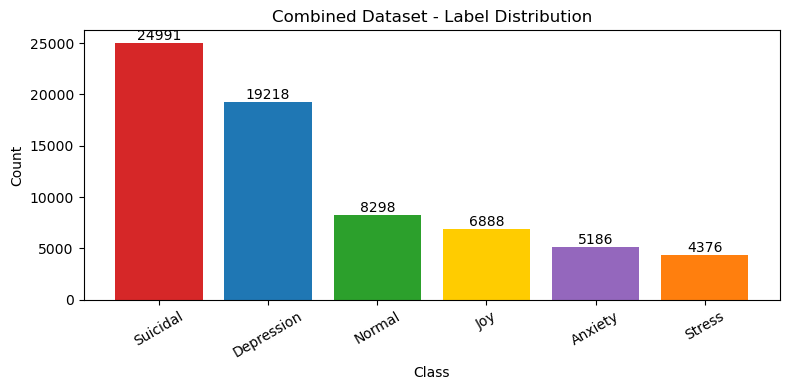

In [71]:
combined_df = pd.concat([mh_df, sw_df,tw_df, em_df], ignore_index=True)
print(f'After concat : {len(combined_df):,} rows')

before_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=['text'])
print(f'After dedup: {len(combined_df):,} rows (removed {before_dedup - len(combined_df):,} duplicates)')

combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_df = combined_df[['text', 'label']]
print(f'Shuffled: {len(combined_df):,} rows')

explore_dataset('Combined Dataset', combined_df)

In [72]:
print(f'Combined dataset: {combined_df.shape[0]:,} rows, {combined_df.shape[1]} columns')
print(f"Duplicates removed: {before_dedup - len(combined_df):,}")
print(f'Missing values: {combined_df.isnull().sum().sum()}')
print()

class_dist = combined_df['label'].value_counts()
print('Class distribution:')
for label, count in class_dist.items():
    pct = count / len(combined_df) * 100
    print(f'  {label:<12} {count:>7,}  ({pct:.1f}%)')

print()
largest = class_dist.iloc[0]
smallest = class_dist.iloc[-1]
ratio = largest / smallest
print(f'Imbalance ratio (largest/smallest): {ratio:.1f}x ({class_dist.index[0]} vs {class_dist.index[-1]})')

Combined dataset: 68,957 rows, 2 columns
Duplicates removed: 6,383
Missing values: 0

Class distribution:
  Suicidal      24,991  (36.2%)
  Depression    19,218  (27.9%)
  Normal         8,298  (12.0%)
  Joy            6,888  (10.0%)
  Anxiety        5,186  (7.5%)
  Stress         4,376  (6.3%)

Imbalance ratio (largest/smallest): 5.7x (Suicidal vs Stress)


In [75]:
combined_df.to_csv(OUTPUT_LABELED_PATH, index=False, encoding='utf-8')
print(f'Saved labeled dataset: {OUTPUT_LABELED_PATH} ({len(combined_df):,} rows)')

cancer_df[['text']].to_csv(OUTPUT_VOCAB_PATH, index=False, encoding='utf-8')
print(f'Saved cancer vocab: {OUTPUT_VOCAB_PATH} ({len(cancer_df):,} rows)')

Saved labeled dataset: ../data/processed/cancer mental health final.csv (68,957 rows)
Saved cancer vocab: ../data/processed/cancer vocab text.csv (10,274 rows)
